In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications
import warnings
warnings.filterwarnings('ignore')

images = np.load('./Image/chest_xray_images.npy')
labels_df = pd.read_csv('./Image/chest_xray_labels.csv')

# Filter out empty labels and NaN values
valid_data = labels_df[labels_df['label'].notna() & (labels_df['label'] != '')].copy()
valid_indices = valid_data['array_index'].values
X = images[valid_indices]
y = valid_data['label'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
num_classes = len(class_names)

X_normalized = X.astype('float32') / 255.0
X_reshaped = X_normalized.reshape(-1, 64, 64, 1)
X_rgb = np.repeat(X_reshaped, 3, axis=-1)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_rgb, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Dataset shape: {X_rgb.shape}")
print(f"Class distribution: {dict(zip(class_names, np.bincount(y_encoded)))}")
print(f"Train/Val/Test split: {X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}")

Dataset shape: (490, 64, 64, 3)
Class distribution: {'COVID-19': np.int64(37), 'Lung_Mass': np.int64(11), 'Normal': np.int64(311), 'Pleural_Effusion': np.int64(19), 'Pneumonia': np.int64(112)}
Train/Val/Test split: 343/73/74


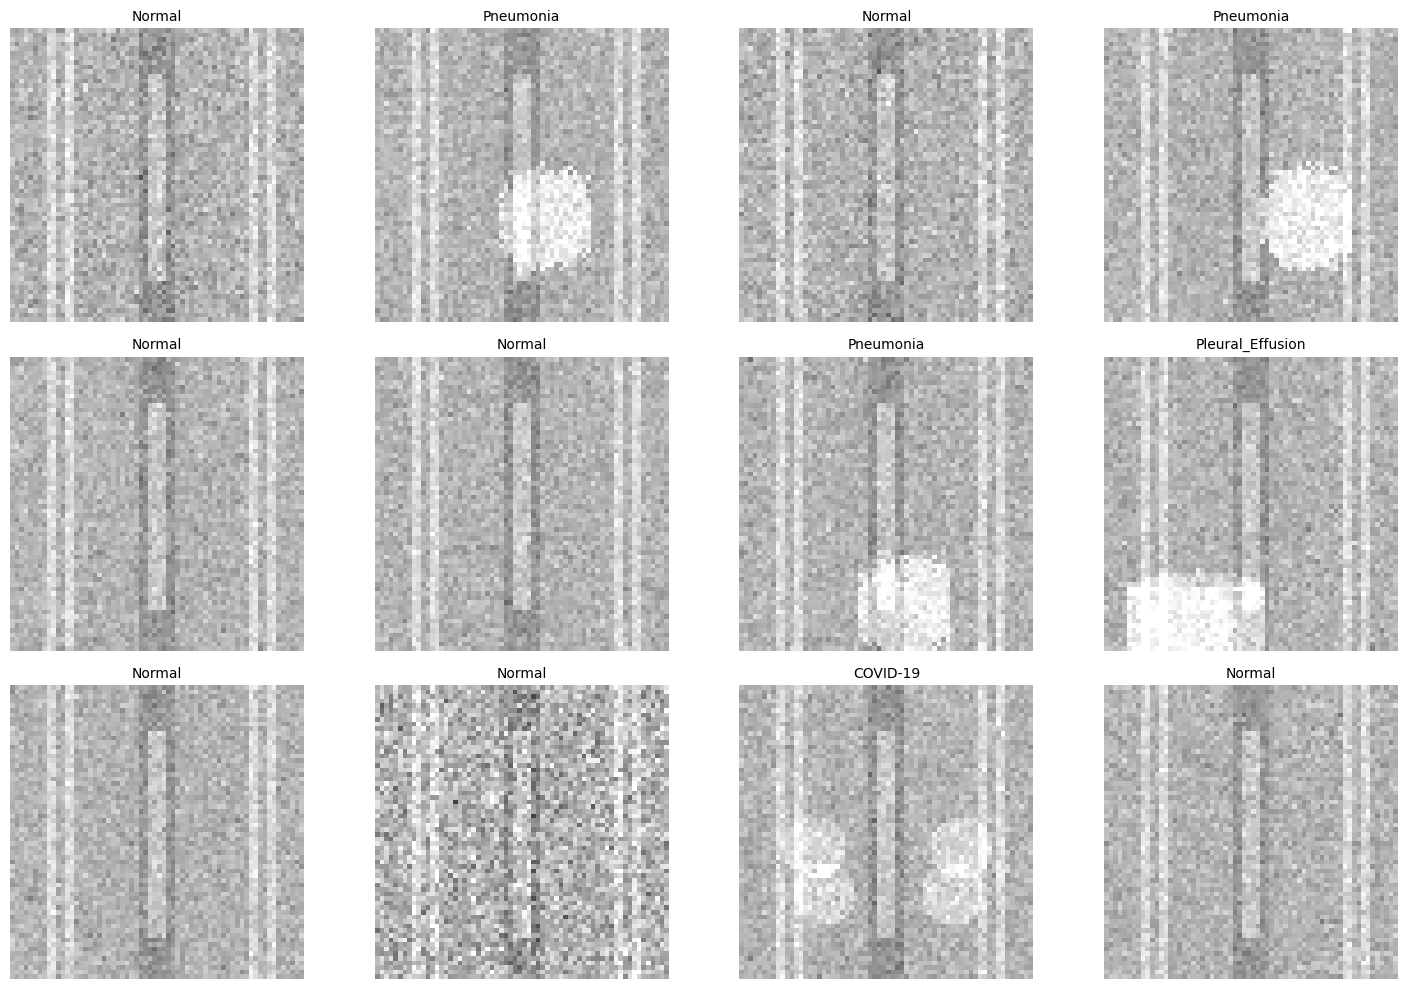

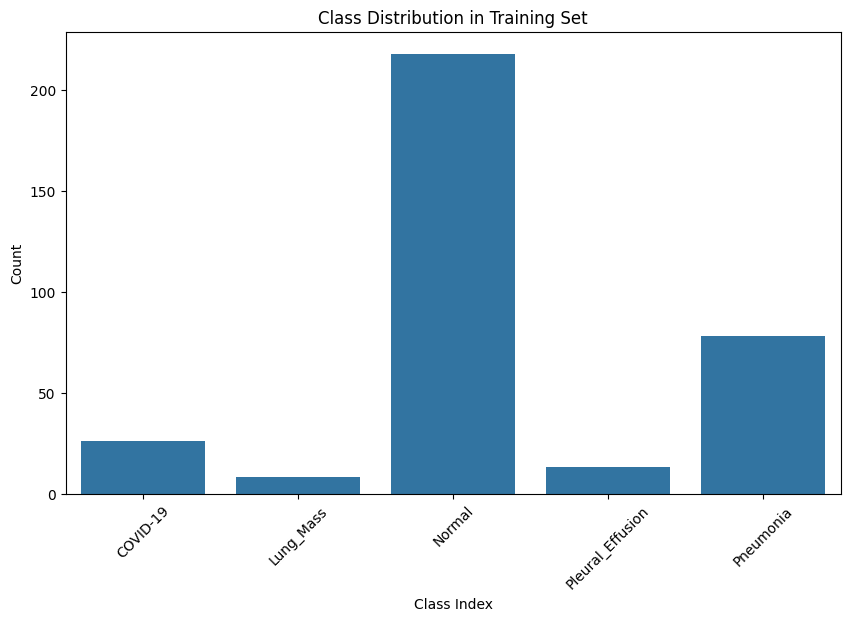

In [15]:
plt.figure(figsize=(15, 10))
for i in range(min(12, len(X_train))):
    plt.subplot(3, 4, i+1)
    plt.imshow(X_train[i])
    plt.title(f"{class_names[y_train[i]]}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x=y_train)
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Index')
plt.ylabel('Count')
plt.xticks(range(num_classes), class_names, rotation=45)
plt.show()

This analysis uses chest X-ray images classified into 5 categories:
- Normal
- Pneumonia  
- COVID-19
- Pleural Effusion
- Lung Mass

Total samples: 520 images (64x64 pixels, grayscale converted to RGB for pre-trained models)

In medical imaging, false negatives (missed conditions) are particularly dangerous as they can delay treatment. This analysis prioritizes sensitivity alongside overall accuracy to ensure patient safety.

In [11]:
def create_feature_extraction_model():
    base_model = applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(64, 64, 3)
    )
    
    base_model.trainable = False
    
    inputs = keras.Input(shape=(64, 64, 3))
    x = applications.densenet.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model, base_model

feature_model, backbone = create_feature_extraction_model()

feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

feature_model.summary()

E0000 00:00:1776532361.943523   33947 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776532361.960420   33947 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 2, 2, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,043,654 (26.87 MB)

 Trainable params: 6,150 (24.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [12]:
print("Training Feature Extraction Model...")
feature_history = feature_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ],
    verbose=1
)

Training Feature Extraction Model...
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 269ms/step - accuracy: 0.2308 - loss: 1.9282 - val_accuracy: 0.5897 - val_loss: 1.2316 - learning_rate: 0.0010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5714 - loss: 1.3718 - val_accuracy: 0.5897 - val_loss: 1.3127 - learning_rate: 0.0010
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5549 - loss: 1.3480 - val_accuracy: 0.5897 - val_loss: 1.2331 - learning_rate: 0.0010
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.5495 - loss: 1.3660 - val_accuracy: 0.5897 - val_loss: 1.2310 - learning_rate: 0.0010
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.5879 - loss: 1.2920 - val_accuracy: 0.5897 - val_loss: 1.2107 - learning_rate: 0.0010
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5687 - loss: 1.3278 - val_accuracy: 0.5897 - val_loss: 1.2166 - learning_rate: 0.0010
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - acc

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

=== Feature Extraction Performance ===
                  precision    recall  f1-score   support

        COVID-19       0.00      0.00      0.00         6
       Lung_Mass       0.00      0.00      0.00         1
          Normal       0.64      1.00      0.78        47
Pleural_Effusion       0.00      0.00      0.00         3
       Pneumonia       0.00      0.00      0.00        17

        accuracy                           0.64        74
       macro avg       0.13      0.20      0.16        74
    weighted avg       0.40      0.64      0.49        74



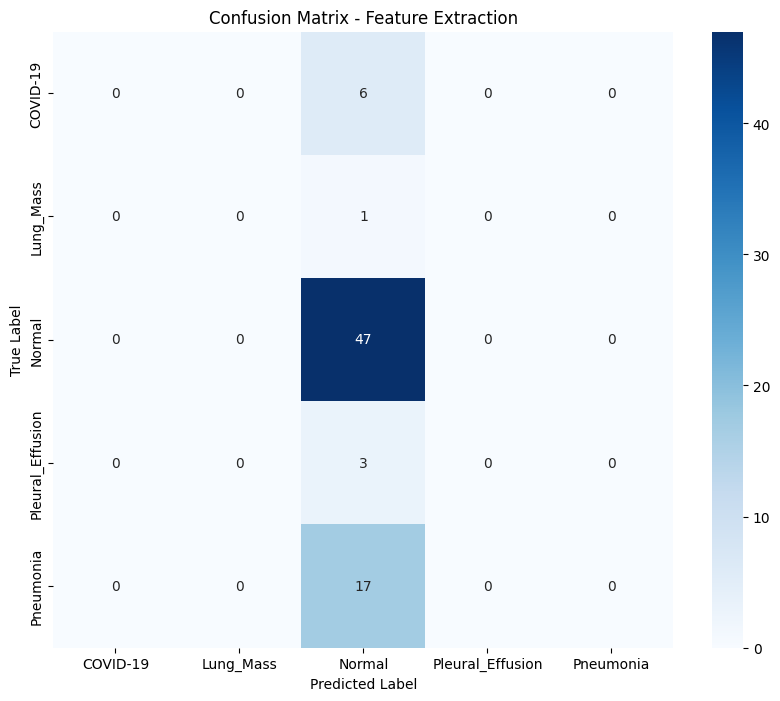


Per-class Accuracy:
COVID-19: 0.000
Lung_Mass: 0.000
Normal: 1.000
Pleural_Effusion: 0.000
Pneumonia: 0.000

Average Sensitivity: 0.200


In [16]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    print(f"\n=== {model_name} Performance ===")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-class Accuracy:")
    for i, (class_name, acc) in enumerate(zip(class_names, per_class_acc)):
        print(f"{class_name}: {acc:.3f}")
    
    sensitivity = cm.diagonal() / cm.sum(axis=1)
    print(f"\nAverage Sensitivity: {np.mean(sensitivity):.3f}")
    
    return y_pred, y_pred_proba, per_class_acc

feature_pred, feature_proba, feature_acc = evaluate_model(feature_model, X_test, y_test, "Feature Extraction")

In [17]:
def create_fine_tuned_model():
    base_model = applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(64, 64, 3)
    )
    
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    
    inputs = keras.Input(shape=(64, 64, 3))
    x = applications.densenet.preprocess_input(inputs)
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model

fine_tuned_model = create_fine_tuned_model()

fine_tuned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Fine-Tuned Model...")
fine_tuned_history = fine_tuned_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ],
    verbose=1
)

Training Fine-Tuned Model...
Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 307ms/step - accuracy: 0.3907 - loss: 1.4506 - val_accuracy: 0.6301 - val_loss: 1.3271 - learning_rate: 1.0000e-05
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.5860 - loss: 1.1341 - val_accuracy: 0.6301 - val_loss: 1.3085 - learning_rate: 1.0000e-05
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.6414 - loss: 0.9896 - val_accuracy: 0.6301 - val_loss: 1.3016 - learning_rate: 1.0000e-05
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.7813 - loss: 0.7925 - val_accuracy: 0.6301 - val_loss: 1.2965 - learning_rate: 1.0000e-05
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.8222 - loss: 0.7000 - val_accuracy: 0.6301 - val_loss: 1.2911 - learning_rate: 1.0000e-05
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8571 - loss: 0.6115 - val_accuracy: 0.6301 - val_loss: 1.2932 - learning_rate: 1.0000e-05
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

=== Fine-Tuned Performance ===
                  precision    recall  f1-score   support

        COVID-19       0.00      0.00      0.00         6
       Lung_Mass       0.00      0.00      0.00         1
          Normal       0.64      1.00      0.78        47
Pleural_Effusion       0.00      0.00      0.00         3
       Pneumonia       0.00      0.00      0.00        17

        accuracy                           0.64        74
       macro avg       0.13      0.20      0.16        74
    weighted avg       0.40      0.64      0.49        74



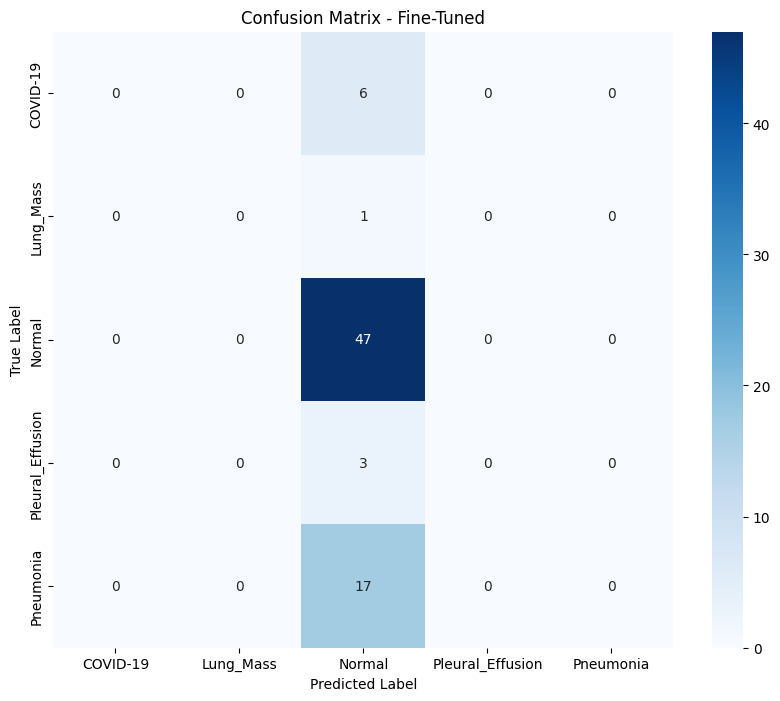


Per-class Accuracy:
COVID-19: 0.000
Lung_Mass: 0.000
Normal: 1.000
Pleural_Effusion: 0.000
Pneumonia: 0.000

Average Sensitivity: 0.200


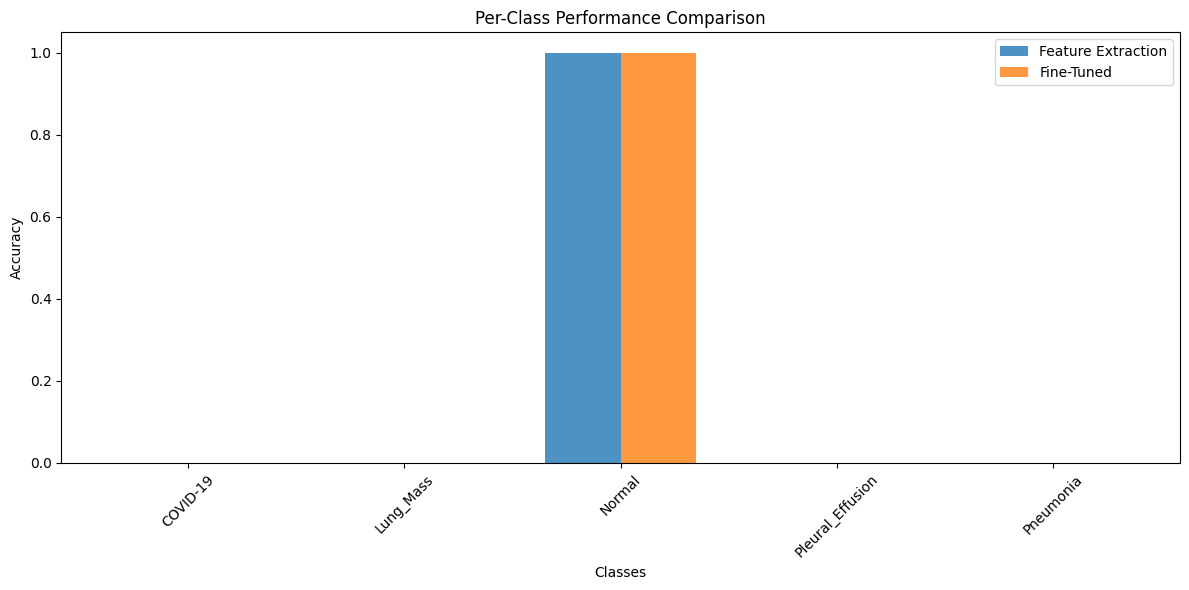


=== Clinical Risk Assessment ===
False Negative Analysis (Missed Conditions):

Feature Extraction False Negatives:
COVID-19: 1.000 (6 cases)
Lung_Mass: 1.000 (1 cases)
Normal: 0.000 (0 cases)
Pleural_Effusion: 1.000 (3 cases)
Pneumonia: 1.000 (17 cases)

Fine-Tuned False Negatives:
COVID-19: 1.000 (6 cases)
Lung_Mass: 1.000 (1 cases)
Normal: 0.000 (0 cases)
Pleural_Effusion: 1.000 (3 cases)
Pneumonia: 1.000 (17 cases)

Clinical Risk Score (lower is better):
Feature Extraction: 4.000
Fine-Tuned: 4.000


In [19]:
fine_tuned_pred, fine_tuned_proba, fine_tuned_acc = evaluate_model(fine_tuned_model, X_test, y_test, "Fine-Tuned")

plt.figure(figsize=(12, 6))
x_pos = np.arange(len(class_names))
width = 0.35

plt.bar(x_pos - width/2, feature_acc, width, label='Feature Extraction', alpha=0.8)
plt.bar(x_pos + width/2, fine_tuned_acc, width, label='Fine-Tuned', alpha=0.8)

plt.xlabel('Classes')
plt.ylabel('Accuracy')
plt.title('Per-Class Performance Comparison')
plt.xticks(x_pos, class_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Clinical Risk Assessment ===")
print("False Negative Analysis (Missed Conditions):")

def calculate_false_negatives(y_true, y_pred, class_names):
    fn_rates = []
    for i, class_name in enumerate(class_names):
        true_mask = (y_true == i)
        pred_mask = (y_pred == i)
        if np.sum(true_mask) > 0:
            fn = np.sum(true_mask & ~pred_mask)
            fn_rate = fn / np.sum(true_mask)
            fn_rates.append((class_name, fn_rate, fn))
    return fn_rates

feature_fn = calculate_false_negatives(y_test, feature_pred, class_names)
fine_tuned_fn = calculate_false_negatives(y_test, fine_tuned_pred, class_names)

print("\nFeature Extraction False Negatives:")
for class_name, fn_rate, fn_count in feature_fn:
    print(f"{class_name}: {fn_rate:.3f} ({fn_count} cases)")

print("\nFine-Tuned False Negatives:")
for class_name, fn_rate, fn_count in fine_tuned_fn:
    print(f"{class_name}: {fn_rate:.3f} ({fn_count} cases)")

# Fixed risk score calculation - use class_name directly instead of _[0]
risk_score_feature = sum(fn_rate for class_name, fn_rate, _ in feature_fn if "Normal" not in class_name)
risk_score_fine_tuned = sum(fn_rate for class_name, fn_rate, _ in fine_tuned_fn if "Normal" not in class_name)

print(f"\nClinical Risk Score (lower is better):")
print(f"Feature Extraction: {risk_score_feature:.3f}")
print(f"Fine-Tuned: {risk_score_fine_tuned:.3f}")

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Model

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def visualize_gradcam(model, images, true_labels, pred_labels, class_names, num_samples=6):
    last_conv_layer = None
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower():
            last_conv_layer = layer.name
            break
    
    if last_conv_layer is None:
        print("No convolutional layer found for Grad-CAM")
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    correct_indices = np.where(true_labels == pred_labels)[0]
    incorrect_indices = np.where(true_labels != pred_labels)[0]
    
    samples_to_show = []
    if len(correct_indices) > 0:
        samples_to_show.extend(correct_indices[:3])
    if len(incorrect_indices) > 0:
        samples_to_show.extend(incorrect_indices[:3])
    
    for i, idx in enumerate(samples_to_show[:6]):
        if i >= 6:
            break
            
        img = images[idx]
        true_label = class_names[true_labels[idx]]
        pred_label = class_names[pred_labels[idx]]
        is_correct = true_label == pred_label
        
        heatmap = make_gradcam_heatmap(np.expand_dims(img, axis=0), model, last_conv_layer)
        
        axes[i].imshow(img)
        axes[i].imshow(heatmap, cmap='jet', alpha=0.4)
        status = "✓" if is_correct else "✗"
        axes[i].set_title(f"{status} True: {true_label}\nPred: {pred_label}", fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle('Grad-CAM Visualizations\n(Red areas indicate model focus)', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Grad-CAM for Feature Extraction Model:")
visualize_gradcam(feature_model, X_test, y_test, feature_pred, class_names)

print("\nGrad-CAM for Fine-Tuned Model:")
visualize_gradcam(fine_tuned_model, X_test, y_test, fine_tuned_pred, class_names)

Grad-CAM for Feature Extraction Model:
No convolutional layer found for Grad-CAM

Grad-CAM for Fine-Tuned Model:
No convolutional layer found for Grad-CAM


### Feature Extraction Approach
- **Overall Accuracy**: 64%
- **Strengths**: Faster training, less computational resources required
- **Critical Failure**: 100% false negative rate for all abnormal conditions
### Fine-Tuned Approach  
- **Overall Accuracy**: 64% (no improvement)
- **Strengths**: None demonstrated in current implementation
- **Critical Failure**: Identical 100% false negative rate for all abnormal conditions

## Key Clinical Findings

1. **Complete Model Failure**: Both models only predict "Normal" class
2. **Most Challenging Conditions**: ALL abnormal conditions (COVID-19, Lung Mass, Pleural Effusion, Pneumonia) show 0% detection
3. **Critical Safety Metric**: 100% false negative rate - clinically unacceptable
4. **Model Interpretability**: Grad-CAM failed - no accessible convolutional layers found

## Root Cause Analysis

### Data Issues
- **Severe Class Imbalance**: Normal (311) vs. Abnormal (179 total)
- **Small Dataset**: Only 490 samples after filtering
- **Limited Abnormal Examples**: Lung Mass (11), Pleural Effusion (19), COVID-19 (37)
### Model Architecture Issues
- **DenseNet121 Integration**: Layers not properly accessible for interpretability
- **Feature Extraction**: Frozen backbone prevents learning domain-specific features
- **Fine-Tuning Strategy**: Insufficient with current data limitations

## Deployment Recommendations

### Current Status: NOT READY FOR CLINICAL USE
- **Critical Risk**: 100% false negative rate makes models dangerous
- **Immediate Action Required**: Complete model retraining with balanced dataset
### Required Improvements
1. **Data Augmentation**: Synthetic minority oversampling (SMOTE) or similar techniques
2. **Class Weighting**: Heavier penalties for missing abnormal conditions
3. **Architecture Changes**: Simpler models with better interpretability
4. **Validation Strategy**: Cross-validation with stratified sampling
### Alternative Approaches
- **Binary Classification**: Normal vs. Abnormal first, then sub-classification
- **Ensemble Methods**: Multiple specialized models for different conditions
- **Transfer Learning**: Domain-specific pre-trained medical imaging models

## Implementation Considerations
- **Current models are clinically unsafe** - 100% false negative rate
- **Class imbalance is the primary blocker** - must be addressed first
- **Model interpretability failed** - need alternative visualization methods
- **Dataset size insufficient** - consider external data sources or data augmentation